# Funding model capability, capture diagnostic

The retraining study and the v2 shape runs both land on the same verdict, persistence is not beaten. This is the one-time diagnostic that attributes that verdict instead of just observing it. It scores the final model by capture, not PnL, to localize exactly where elastic and gbm miss.

Switching to capture does not re-rank anything, net PnL is captured funding minus fees over a fixed available ceiling, so a source that loses on PnL loses on capture too. The point is attribution. Funding available is the cost-free positive-funding ceiling a perfect-foresight harvester could collect. Captured is what each source's strategy actually gets. The decomposition into capture, fee drag and basis, cut by year, regime and symbol, says whether persistence wins on grabbing more funding or only on turnover, and whether the model ever adds timing skill.

Final live policy, expanding window, monthly refit. Threshold decisions are the 34 bp round-trip hurdle unless swept.

## Setup and out-of-fold predictions

Same feature pipeline, walk-forward folds and causal generator as the retraining study. One expanding, monthly policy, regenerated in memory.

In [1]:
import os, sys, glob, warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / "research").is_dir():
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
import research.features as F
import research.cv as CV
from research.models import _with_symbol_dummies

_so = glob.glob(str(REPO / "build" / "release" / "**" / "qp_python_backtest*.so"), recursive=True)
sys.path.insert(0, os.path.dirname(_so[0]))
import qp_python_backtest as qb

DATA       = REPO / "data" / "binance_historical"
COST_TABLE = str(REPO / "data" / "cost_model" / "cost_table.csv")
SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT", "XRPUSDT",
           "DOGEUSDT", "ADAUSDT", "LINKUSDT", "AVAXUSDT", "LTCUSDT"]
NAME_TO_ID = {n: i for i, n in enumerate(SYMBOLS)}
ID_TO_NAME = {i: n for n, i in NAME_TO_ID.items()}
FUT, SPOT = 0, 1
HORIZON = 24
HURDLE = 0.0034
SOURCES = ["persistence", "elastic", "gbm"]

In [2]:
FUNDING_COLS = ["symbol", "tag", "ts_ms", "interval_h", "funding_rate"]
PREMIUM_COLS = ["ts_ms", "open", "high", "low", "close", "volume", "close_ms",
                "quote_vol", "trades", "taker_buy_base", "taker_buy_quote", "ignore"]


def load_funding(sym):
    d = DATA / sym / "futures" / "funding"
    files = sorted(d.glob(f"{sym}-fundingRate-*.csv"))
    df = pd.concat([pd.read_csv(f, header=None, names=FUNDING_COLS) for f in files], ignore_index=True)
    df["ts"] = pd.to_datetime(df["ts_ms"], unit="ms", utc=True)
    df["symbol"] = sym
    return (df[["symbol", "ts", "funding_rate"]].rename(columns={"funding_rate": "realized_funding"})
            .sort_values("ts").drop_duplicates("ts").reset_index(drop=True))


def load_premium(sym):
    d = DATA / sym / "futures" / "premiumindex"
    files = sorted(d.glob("*.csv"))
    if not files:
        return pd.DataFrame(columns=["ts_ms", "close"])
    parts = [pd.read_csv(f, header=None, names=PREMIUM_COLS)[["ts_ms", "close"]] for f in files]
    df = pd.concat(parts, ignore_index=True).sort_values("ts_ms").drop_duplicates("ts_ms").reset_index(drop=True)
    df["ts"] = pd.to_datetime(df["ts_ms"], unit="ms", utc=True)
    return df


def average_premium_up_to(premium, funding_ts, interval_hours=8):
    if premium.empty:
        return pd.Series(np.nan, index=range(len(funding_ts)))
    p = premium.sort_values("ts").reset_index(drop=True)
    win = pd.Timedelta(hours=interval_hours)
    out = np.full(len(funding_ts), np.nan)
    ts_vals = pd.to_datetime(funding_ts, utc=True).to_numpy()
    p_ts = p["ts"].to_numpy(); p_close = p["close"].to_numpy(dtype=float)
    for i, end in enumerate(ts_vals):
        lo = np.searchsorted(p_ts, end - win, side="right")
        hi = np.searchsorted(p_ts, end, side="right")
        if hi > lo:
            out[i] = p_close[lo:hi].mean()
    return pd.Series(out)


parts = []
for sym in SYMBOLS:
    f = load_funding(sym); p = load_premium(sym)
    f["premium"] = average_premium_up_to(p, f["ts"]).to_numpy()
    parts.append(f)
events = pd.concat(parts, ignore_index=True)

feat = events.copy()
for k in (1, 2, 3):
    feat = F.add_funding_lag(feat, k)
feat = F.add_funding_ewma(feat, halflife=2); feat = F.add_funding_ewma(feat, halflife=6)
feat = F.add_funding_vol(feat, window=8); feat = F.add_clamp_distance(feat)
feat = F.add_premium_trend(feat, span=3); feat = F.add_cross_symbol_spread(feat, reference="BTCUSDT")
feat = F.add_basket_spread(feat); feat = F.add_time_features(feat)
feat = F.add_funding_mean_window(feat, window=90); feat = F.add_funding_sign_window(feat, window=90)
feat = F.add_funding_vol_rank(feat, vol_window=30, rank_window=180)
kline_agg = pd.read_pickle(REPO / "research" / "results" / "kline_aggregates_8h.pkl")
feat = feat.merge(kline_agg, on=["symbol", "ts"], how="left")
feat["taker_imb_x_ewma2"] = feat["taker_imbalance"] * feat["funding_ewma_h2"]
feat["taker_imb_x_lag1"] = feat["taker_imbalance"] * feat["funding_lag1"]
feat["vol1m_x_clamp"] = feat["realized_vol_1m"] * feat["clamp_distance"]
feat["range_x_ewma2"] = feat["high_low_range"] * feat["funding_ewma_h2"]
feat["regime_x_lag1"] = feat["funding_sign_w90"] * feat["funding_lag1"]
feat["basket_x_lag1"] = feat["basket_spread"] * feat["funding_lag1"]
feat["lag1_sq"] = feat["funding_lag1"] ** 2
feat = F.add_basket_zscore(feat, source="funding_lag1")
feat = F.add_basket_zscore(feat, source="funding_ewma_h6")
feat = F.add_basket_rank(feat, source="funding_lag1")
feat["basket_z_x_lag1"] = feat["basket_z_funding_lag1"] * feat["funding_lag1"]
feat["basket_rank_x_lag1"] = feat["basket_rank_funding_lag1"] * feat["funding_lag1"]
feat = F.add_cum_target(feat, horizon=HORIZON)
FCOLS = [c for c in feat.columns
         if c not in ("symbol", "ts", "realized_funding", "premium", "realized_cum")]
feat = feat.dropna(subset=FCOLS + ["realized_funding", "realized_cum"]).reset_index(drop=True)
feat["year"] = feat["ts"].dt.year
folds = list(CV.walk_forward_splits(feat, n_folds=5, horizon=HORIZON, embargo=5))
fold_of = np.full(len(feat), -1)
for fi, (_, te) in enumerate(folds):
    fold_of[te] = fi
feat["fold"] = fold_of
print("feat", feat.shape, "features", len(FCOLS))

feat (32058, 38) features 31


In [3]:
PURGE = pd.Timedelta(hours=HORIZON * 8)


def elastic_pred(train, test, cols):
    Xtr, _ = _with_symbol_dummies(train, cols)
    pipe = Pipeline([("sc", StandardScaler()),
                     ("m", ElasticNet(alpha=1e-4, l1_ratio=0.7, max_iter=20000))])
    pipe.fit(Xtr, train["realized_cum"].to_numpy())
    Xte, _ = _with_symbol_dummies(test, cols)
    return pipe.predict(Xte)


def gbm_pred(train, test, cols):
    import lightgbm as lgb
    Xtr, c = _with_symbol_dummies(train, cols)
    y = train["realized_cum"].to_numpy(); sp = int(len(y) * 0.8)
    p = dict(objective="regression", verbose=-1, feature_fraction=0.9, bagging_fraction=0.9,
             bagging_freq=5, learning_rate=0.02, num_leaves=15, min_data_in_leaf=500)
    dtr = lgb.Dataset(Xtr[:sp], label=y[:sp], feature_name=c)
    dval = lgb.Dataset(Xtr[sp:], label=y[sp:], reference=dtr)
    b = lgb.train(p, dtr, num_boost_round=3000, valid_sets=[dval],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    Xte, _ = _with_symbol_dummies(test, cols)
    return b.predict(Xte, num_iteration=b.best_iteration)


MODELS = {"elastic": elastic_pred, "gbm": gbm_pred}


def gen_policy_oof(window_months, refit_freq, min_train=2000):
    test = feat[feat.fold >= 0]
    start = pd.Timestamp(test.ts.min()).tz_convert("UTC").normalize().replace(day=1)
    dates = pd.date_range(start, test.ts.max(), freq=refit_freq, tz="UTC")
    di = np.searchsorted(dates.to_numpy(), test.ts.to_numpy(), side="right") - 1
    out = test[["symbol", "ts", "fold", "year", "realized_funding",
                "realized_cum", "funding_lag1"]].copy()
    for name in MODELS:
        out["pred_" + name] = np.nan
    out["pred_persistence"] = (HORIZON * test["funding_lag1"]).to_numpy()
    for k, d in enumerate(dates):
        sl = test[di == k]
        if sl.empty:
            continue
        tr = feat[feat.ts <= d - PURGE]
        if window_months is not None:
            tr = tr[tr.ts >= d - pd.DateOffset(months=window_months)]
        if len(tr) < min_train:
            continue
        for name, fn in MODELS.items():
            out.loc[sl.index, "pred_" + name] = fn(tr, sl, FCOLS)
    return out


oof = gen_policy_oof(None, "MS").dropna(subset=["pred_elastic", "pred_gbm"])
oof = oof.sort_values(["symbol", "ts"]).reset_index(drop=True)
print("oof rows", len(oof), "window", oof.ts.min().date(), "to", oof.ts.max().date())

oof rows 22448 window 2022-12-07 to 2024-12-24


## Capture, available and held

The harvest is one number. Available is the funding a perfect-foresight harvester collects, the sum of positive realized funding over the window. Captured is the funding collected on the prints a source actually holds, its threshold decision times the realized funding. Capture ratio is the fraction of the available ceiling a source grabs. Hold fraction is how often it is in. A source with no timing skill captures the same fraction persistence does at the same hold fraction.

In [4]:
avail = oof.realized_funding.clip(lower=0)


def cap_table(df):
    A = avail.loc[df.index].sum()
    rows = []
    for src in SOURCES:
        held = (df["pred_" + src] >= HURDLE)
        rows.append({"source": src,
                     "capture_ratio": (held * df.realized_funding).sum() / A if A else np.nan,
                     "hold_frac": held.mean()})
    return pd.DataFrame(rows).set_index("source").round(3), A


print("=== all ===")
t, A = cap_table(oof); print(t, "\navailable_rate", round(A, 4))
print("\n=== by year ===")
for y in sorted(oof.year.unique()):
    t, A = cap_table(oof[oof.year == y])
    print(f"-- {y}  available_rate {A:.4f}"); print(t)
print("\n=== BTC vs alts ===")
for g, m in [("BTC", oof.symbol == "BTCUSDT"), ("alts", oof.symbol != "BTCUSDT")]:
    t, A = cap_table(oof[m]); print(f"-- {g}  available_rate {A:.4f}"); print(t)

=== all ===
             capture_ratio  hold_frac
source                               
persistence          0.381      0.122
elastic              0.373      0.122
gbm                  0.344      0.122 
available_rate 2.2021

=== by year ===
-- 2022  available_rate 0.0290
             capture_ratio  hold_frac
source                               
persistence            0.0        0.0
elastic                0.0        0.0
gbm                    0.0        0.0
-- 2023  available_rate 0.8843
             capture_ratio  hold_frac
source                               
persistence          0.212      0.070
elastic              0.131      0.032
gbm                  0.000      0.000
-- 2024  available_rate 1.2888
             capture_ratio  hold_frac
source                               
persistence          0.505      0.184
elastic              0.548      0.223
gbm                  0.587      0.255

=== BTC vs alts ===
-- BTC  available_rate 0.2054
             capture_ratio  hold_frac
source

Persistence captures the most, at an identical hold fraction. Overall it is 0.381 against elastic 0.373 and gbm 0.344, all holding 12 percent of prints. The models do not grab more funding for the prints they pick, they grab slightly less. By year the split is stark: 2022 has no funding to harvest, in the lean 2023 persistence captures 0.21 against elastic 0.13 and gbm 0.00, and only in the fat 2024 do the models edge ahead, 0.59 gbm to 0.51 persistence, and they do it by holding more, 0.26 against 0.18, not by picking better. The model's apparent 2024 win is regime beta, being more aggressive when funding is high, and it costs them the whole of 2023. Only on BTC does the model edge persistence, 0.36 to 0.31, the thin known edge, and persistence wins the alts.

## Hurdle sweep

If the models have real selectivity they should separate from persistence at some entry level, capturing more funding for the prints they hold. Sweep the hurdle from half the round trip to twice it.

            persistence  elastic    gbm
hurdle_bps                             
17.0              0.857    0.655  0.690
34.0              0.381    0.373  0.344
51.0              0.316    0.195  0.239
68.0              0.258    0.091  0.037 

            persistence_hold  elastic_hold  gbm_hold
hurdle_bps                                          
17.0                    0.63          0.37      0.41
34.0                    0.12          0.12      0.12
51.0                    0.09          0.04      0.07
68.0                    0.06          0.02      0.01


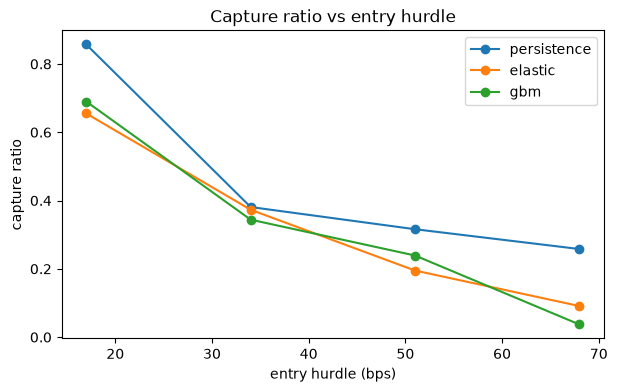

In [5]:
rows = []
for mult in [0.5, 1.0, 1.5, 2.0]:
    h = HURDLE * mult; r = {"hurdle_bps": round(h * 1e4, 1)}
    for src in SOURCES:
        held = (oof["pred_" + src] >= h)
        r[src] = round((held * oof.realized_funding).sum() / avail.sum(), 3)
        r[src + "_hold"] = round(held.mean(), 2)
    rows.append(r)
sweep = pd.DataFrame(rows).set_index("hurdle_bps")
print(sweep[SOURCES], "\n")
print(sweep[[s + "_hold" for s in SOURCES]])

plt.figure(figsize=(7, 4))
for src in SOURCES:
    plt.plot(sweep.index, sweep[src], marker="o", label=src)
plt.xlabel("entry hurdle (bps)"); plt.ylabel("capture ratio"); plt.legend()
plt.title("Capture ratio vs entry hurdle"); plt.show()

Persistence is on top at every hurdle. At a loose 17 bps it captures 0.86 against the models' 0.66 to 0.69, and as the hurdle tightens the gap widens, at 68 bps persistence holds 0.26 while elastic and gbm collapse to 0.09 and 0.04. There is no operating point where the models' extra selectivity pays. The one-print rule sits on the capture frontier and the models sit below it everywhere.

## Where the funding is, magnitude buckets

Split the positive-funding prints into rank quartiles and read the fraction of each bucket's funding captured. This says which prints carry the harvest and who grabs them.

In [6]:
pos = oof[oof.realized_funding > 0].copy()
pos["bucket"] = pd.qcut(pos.realized_funding.rank(method="first"), 4,
                        labels=["q1_low", "q2", "q3", "q4_high"])
rows = []
for src in SOURCES:
    g = pos.groupby("bucket", observed=True).apply(
        lambda d: (d["pred_" + src] >= HURDLE).astype(float).mul(d.realized_funding).sum()
        / d.realized_funding.sum())
    rows.append(pd.Series(g, name=src))
print(pd.DataFrame(rows).round(3))

bucket       q1_low     q2     q3  q4_high
persistence   0.006  0.036  0.036    0.721
elastic       0.000  0.034  0.048    0.702
gbm           0.001  0.044  0.073    0.630


The harvest is entirely the top quartile. Every source captures near zero in q1 to q3 and 0.63 to 0.72 in q4, the highest-funding prints, because the 34 bp hurdle only clears when funding is already large. Persistence captures the most of that decisive bucket, 0.72 against gbm's 0.63. The models pick up a touch more in the middle buckets where the absolute funding is negligible, and give it back where the money actually is.

## Regime onset, does anyone call the turn

The only place a model could beat a lagged rule is the start of a funding regime, holding before funding has already risen. Split each symbol's positive-funding episodes into the first three prints and the settled remainder.

In [7]:
pp = (oof.realized_funding > 0).to_numpy()
sym = oof.symbol.to_numpy()
new_ep = pp & ((np.roll(sym, 1) != sym) | ~np.roll(pp, 1) | (np.arange(len(pp)) == 0))
epid = np.cumsum(new_ep) * pp
pos_in = pd.DataFrame({"epid": epid}).groupby("epid").cumcount().to_numpy()
oof["pos_in"] = np.where(pp, pos_in, -1)

onset = oof[pp & (oof.pos_in < 3)]
mid = oof[pp & (oof.pos_in >= 3)]
print(f"onset available_rate {onset.realized_funding.sum():.4f}  "
      f"mid available_rate {mid.realized_funding.sum():.4f}\n")
rows = []
for src in SOURCES:
    co = (onset["pred_" + src] >= HURDLE).astype(float).mul(onset.realized_funding).sum() / onset.realized_funding.sum()
    cm = (mid["pred_" + src] >= HURDLE).astype(float).mul(mid.realized_funding).sum() / mid.realized_funding.sum()
    rows.append({"source": src, "onset_capture": round(co, 3),
                 "onset_hold": round((onset["pred_" + src] >= HURDLE).mean(), 2),
                 "mid_capture": round(cm, 3),
                 "mid_hold": round((mid["pred_" + src] >= HURDLE).mean(), 2)})
print(pd.DataFrame(rows).set_index("source"))

onset available_rate 0.2097  mid available_rate 1.9924

             onset_capture  onset_hold  mid_capture  mid_hold
source                                                       
persistence          0.039        0.02        0.417      0.18
elastic              0.000        0.00        0.413      0.18
gbm                  0.001        0.00        0.380      0.18


Nobody calls the turn. Onset capture is persistence 0.039, elastic 0.000, gbm 0.001, every source is flat for the first three prints of a regime and only harvests the middle, around 0.40. The models are no better than persistence here, slightly worse, because their inputs are built from past funding and cannot lead a turn any more than the last print can. And onset is only a tenth of the available funding, 0.21 against 1.99 mid, so there is not much there to chase even if a signal could see it. This is the cleanest answer to the adaptive-retrigger idea: the miss at the turn is structural to a lagged signal, and it is a small pool.

## Head to head on disagreement

On the prints where a model and persistence choose differently, whose picks carry more funding. This isolates the model's own decisions from the funding both would have caught.

In [8]:
hp = (oof["pred_persistence"] >= HURDLE)
for src in ["elastic", "gbm"]:
    hm = (oof["pred_" + src] >= HURDLE)
    om = oof[hm & ~hp]; op = oof[~hm & hp]
    print(f"{src}: model-only {len(om)} prints, funding {om.realized_funding.sum():.4f}   "
          f"persist-only {len(op)} prints, funding {op.realized_funding.sum():.4f}")

elastic: model-only 762 prints, funding 0.1226   persist-only 761 prints, funding 0.1398
gbm: model-only 920 prints, funding 0.1348   persist-only 922 prints, funding 0.2175


Persistence's picks win the disagreements. Where only elastic holds it collects 0.123 against the 0.140 on the prints only persistence holds, and gbm is worse, 0.135 against 0.218, on roughly equal counts. The funding the model adds by deviating from persistence is less than the funding it drops. Its extra information is net negative.

## Decision quality, coverage and precision

A capture ratio is value weighted, so sizing and magnitude move it. The cleanest view of the decision itself is the classifier's, unit free and size free. The target is cost aware, a print is worth opening when the realized next-24 funding clears the round trip, realized_cum at or above the 34 bp hurdle, not merely when funding is positive.

Coverage is the fraction of the worth-opening prints a source is actually in. False-in is the fraction of the not-worth prints it is in anyway, paying to sit. Precision is the fraction of the prints it holds that were worth it.

In [9]:
worth = oof["realized_cum"] >= HURDLE
print(f"worth opening (cum >= 34 bp): {int(worth.sum())} of {len(oof)}  ({worth.mean():.1%})")
rows = []
for src in SOURCES:
    hold = oof["pred_" + src] >= HURDLE
    rows.append({"source": src,
                 "coverage": round(hold[worth].mean(), 3),
                 "false_in": round(hold[~worth].mean(), 3),
                 "precision": round(worth[hold].mean(), 3) if hold.any() else np.nan})
display(pd.DataFrame(rows).set_index("source"))

worth opening (cum >= 34 bp): 3620 of 22448  (16.1%)


,coverage,false_in,precision
source,,,
persistence,0.570,0.036,0.753
elastic,0.561,0.038,0.740
gbm,0.558,0.038,0.737


Only 16 percent of prints are worth opening. Against that target elastic and gbm are indistinguishable from persistence, coverage 0.56 against 0.57, precision 0.74 against 0.75, false-in 0.038 against 0.036. As classifiers of which print to hold they draw the same boundary, catch the same worth-opening prints and miss the same ones. The 43 percent of worth-opening prints all three miss is irreducible forecast error, the signal cannot see those turns ahead and the model recovers none of them. This is the rule-out at the decision level, beneath the capture ratio and the dollars, the model makes persistence's decisions.

Sign, not cost, would have hidden it. Funding is positive on 81 percent of prints, so coverage against funding above zero looks tiny and precision near perfect for everyone, the base rate drowns the signal. The worth-opening target is the honest one.

## Dollar decomposition

The same in engine dollars, the two winning strategies against a perfect-foresight oracle that holds one unit whenever funding is positive. Funding net, fee drag as a fraction of it, basis split out, and capture in dollars against the oracle.

In [10]:
class PredThreshold:
    def __init__(self, bt, pred, qty=1.0, enter=0.0034, exit=0.0):
        self.bt = bt; self.pred = pred; self.qty = qty; self.enter = enter; self.exit = exit
    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        p = self.pred.get((ev.symbol, ev.ts))
        if p is None:
            return None
        held = self.bt.position(ev.symbol, SPOT)
        t = self.qty if p >= self.enter else (0.0 if p <= self.exit else held)
        return [qb.Intent(ev.symbol, SPOT, t), qb.Intent(ev.symbol, FUT, -t)]
    def on_timer(self, now):
        return None


class PredPartialAdjust:
    def __init__(self, bt, pred, hurdle=0.0034, cap=2.0, adjust=0.15):
        self.bt = bt; self.pred = pred; self.hurdle = hurdle; self.cap = cap; self.adjust = adjust
    def on_event(self, ev):
        if ev.kind != qb.EventKind.Funding or ev.venue != FUT:
            return None
        p = self.pred.get((ev.symbol, ev.ts))
        if p is None:
            return None
        aim = float(np.clip(p / self.hurdle, 0.0, self.cap))
        cur = self.bt.position(ev.symbol, SPOT)
        t = cur + self.adjust * (aim - cur)
        return [qb.Intent(ev.symbol, SPOT, t), qb.Intent(ev.symbol, FUT, -t)]
    def on_timer(self, now):
        return None


class Gate:
    def __init__(self, bt, cap=10.0):
        self.bt = bt; self.cap = cap; self._id = 1
    def _next(self):
        i = self._id; self._id += 1; return i
    def check(self, it):
        cur = self.bt.position(it.symbol, it.venue)
        t = float(np.clip(it.target_position, -self.cap, self.cap)); d = t - cur
        out = qb.RiskOutcome.Approved if t == it.target_position else qb.RiskOutcome.Resized
        side = qb.Side.Buy if d >= 0 else qb.Side.Sell
        return qb.RiskDecision(out, qb.Order(self._next(), it.symbol, side, it.venue, abs(d)))


PF = oof.ts.min().date().isoformat(); PL = oof.ts.max().date().isoformat()


def pred_map(col):
    d = oof.dropna(subset=[col])
    sid = d.symbol.map(NAME_TO_ID).to_numpy()
    tns = (d.ts.dt.tz_convert("UTC").dt.tz_localize(None)
           .values.astype("datetime64[ns]").astype("int64"))
    return dict(zip(zip(sid, tns), d[col]))


def run(pm, mk):
    ds = qb.Dataset(str(DATA), SYMBOLS, PF, PL, COST_TABLE)
    bt = qb.PythonBacktest(ds)
    st = mk(bt, pm); g = Gate(bt)
    bt.set_on_event(st.on_event); bt.set_on_timer(st.on_timer); bt.set_check(g.check)
    bt.set_event_kinds([qb.EventKind.Funding])
    r = bt.run()
    return dict(final=r.final_equity, basis=float(np.sum(r.basis_pnl)),
                fn=float(np.sum(r.funding_received)) - float(np.sum(r.funding_paid)),
                fees=float(np.sum(r.fees)))


oof["oracle"] = oof.realized_funding  # hold one unit whenever this print's funding is positive
orc = run(pred_map("oracle"), lambda bt, p: PredThreshold(bt, p, 1.0, 1e-9, 0.0))
print("oracle available funding_net", round(orc["fn"], 1))

rows = []
for sname, mk in [("threshold", lambda bt, p: PredThreshold(bt, p, 1.0, 0.0034, 0.0)),
                  ("partial", lambda bt, p: PredPartialAdjust(bt, p, 0.0034, 2.0, 0.15))]:
    for src in SOURCES:
        r = run(pred_map("pred_" + src), mk)
        rows.append({"strategy": sname, "source": src,
                     "funding_net": round(r["fn"], 1), "fees": round(r["fees"], 1),
                     "fee_drag": round(r["fees"] / r["fn"], 3) if r["fn"] else np.nan,
                     "basis": round(r["basis"], 1), "final": round(r["final"], 1),
                     "cap_vs_oracle": round(r["fn"] / orc["fn"], 3)})
display(pd.DataFrame(rows).set_index(["strategy", "source"]))

oracle available funding_net 11342.8


funding_net    fees  fee_drag  basis    final  \
strategy  source                                                       
threshold persistence       8684.3   380.1     0.044   31.2   8580.0   
          elastic           8761.4   271.0     0.031   31.2   8692.2   
          gbm               7783.2   155.2     0.020   31.2   7843.3   
partial   persistence      11704.1  2426.8     0.207   20.5   9679.3   
          elastic          10765.1  1425.3     0.132   17.7   9756.5   
          gbm              11127.9  1101.0     0.099   17.4  10437.8   

                       cap_vs_oracle  
strategy  source                      
threshold persistence          0.766  
          elastic              0.772  
          gbm                  0.686  
partial   persistence          1.032  
          elastic              0.949  
          gbm                  0.981

The dollars tell the same story and name the mechanism. On the threshold rule every source captures about three quarters of the one-unit oracle at a low fee drag, elastic 0.77 and persistence 0.77 essentially tied, gbm behind at 0.69. On partial adjustment the decisive line is gbm: it wins the final PnL, 10438, not by harvesting more funding but by churning less. Persistence's partial actually collects more gross funding, 11704 against gbm's 11128, and loses it to fees, a 0.207 drag against gbm's 0.099. The model's entire contribution is a smoother prediction series that rebalances less often. That is a turnover property, not a forecast, and the partial-adjust mechanism or an ewma on the last print buys the same smoothness without a model.

Basis is negligible throughout, 17 to 31 dollars on an 8 to 10k PnL, so the equity is honestly funding and the soft Sharpe is regime and tail, not basis noise.

Read cap_vs_oracle with care. The oracle holds one unit, the partial-adjust book sizes up to two, so on partial it runs bigger than the oracle on strong-funding prints and its funding dollars exceed the one-unit ceiling, which is why persistence shows 1.032. That is not 103 percent of available funding, it is a one-unit book being outsized by a two-unit one. The column is a fair capture fraction only on the threshold rule, which also holds one unit. The clean, unit-consistent capture number is the one-unit signal ratio above, 0.38 to 0.43.

## Read

ML is ruled out for this, on every cut. Persistence captures at least as much of the available funding as elastic or gbm at every hurdle, in the decisive top bucket, and by year except 2024 where the model's edge is regime beta that costs it all of 2023. Nobody calls the regime onset, and the miss there is structural to a lagged signal and a small pool anyway. On the prints where the models deviate from persistence they lose more funding than they add. The one dollar win, gbm on partial adjustment, is pure turnover, a smoother signal churning less, not skill, and smoothness is available without a model.

So the rule-out is not just PnL, it is capability. The signal's content is in the last print and persistence already holds it. ML for funding-level prediction is closed. The levers remain cost, structure and risk, maker execution, the short side, and a regime or tail model whose target is book drawdown, not the funding level. If ML re-enters it is there, as danger detection, not forecasting.